In [4]:
#importando bibliotecas
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
%matplotlib inline

import requests
from io import BytesIO

In [5]:
#carrega a base de bados
df = pd.read_csv('/Users/claudiojacomassi/Documents/GitHub/Exercicio Aula Aprendizado de Máquina Não Supervisionado 1/vinhos_dataset.csv', index_col=0)

In [6]:
#mostra cabecario e primeiras 5 linhas
df.head()

,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
fixed_acidity,,,,,,,,,,,,
7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


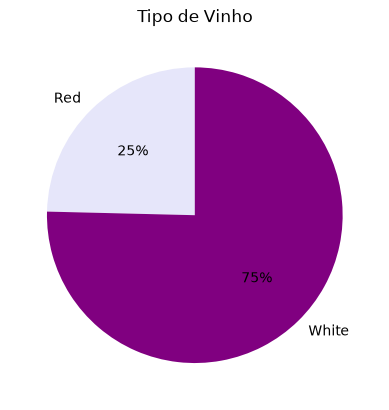

In [8]:
# PLotando em formato pizza a quantidade em % de vinhos red e white
num_red = df[df['color'] == 'red'].shape[0]
num_white = df[df['color'] == 'white'].shape[0]
plt.pie(
    [num_red, num_white],
    labels=['Red', 'White'],
    startangle=90,
    autopct='%1.f%%',
    colors=['lavender', 'purple'])
plt.title('Tipo de Vinho')
plt.show()

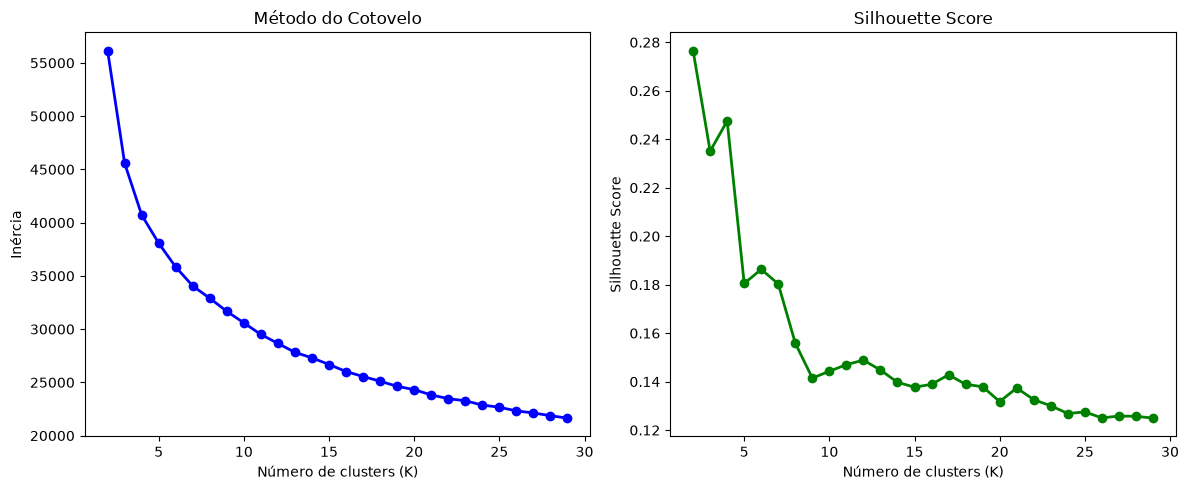

In [9]:
#importando bibliotecas faltantes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Carrega a df novamente (nao entendi porque teve que carregar novamente ?)
df = pd.read_csv(
    "/Users/claudiojacomassi/Documents/GitHub/Exercicio Aula Aprendizado de Máquina Não Supervisionado 1/vinhos_dataset.csv"
)

# Seleciona todos os "features" exceto qualidade e cor
features = [
    'fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'free_sulfur_dioxide',
    'total_sulfur_dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

X = df[features]

# Faz o scaler dos "features" usando o standardscaler e transforma usando a formula z = X - X_mean / X_std - agora todos os valores estao em escalas parecidas e nao pH entre 1 e 14 e sultatios entre 0 e 1 por examplo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Teste do numero de clusters (nao funcionou com 1 a 30)
ks = range(2, 30)

inercias = []
silhouettes = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=1e-4,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    # Inercia
    inercias.append(km.inertia_)

    # Silhouette
    silhouettes.append(
        silhouette_score(X_scaled, labels)
    )

# Plota os diagnosticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
ax1.plot(ks, inercias, 'bo-', linewidth=2)
ax1.set_title('Método do Cotovelo')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inércia')

# Silhouette
ax2.plot(ks, silhouettes, 'go-', linewidth=2)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [13]:
# K-Means com 9 clusters (do grafico de Silhoetes (distancia entre pontos mesmo cluster e distancia de outros clusters) no ponto de inflexao ja que o ponto de inflexao de inercia (distancia entre pontos do mesmo cluster) nao e muito nitido)
kmeans = KMeans(
    n_clusters=9,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

# Ajusta o modelo e atribui cada vinho a um cluster
df['cluster'] = kmeans.fit_predict(X_scaled)

# contagem de vinhos red e whites de cada cluster
cluster_color = pd.crosstab(
    df['cluster'],
    df['color']
)

print(cluster_color)

color    red  white
cluster            
0        520     11
1          3    889
2         20   1076
3        483     32
4         27    882
5        508     38
6          1    864
7          5   1098
8         32      8


In [ ]:
# Resumo de cada cluster

summary = df.groupby('cluster')[features + ['quality']].agg(
    ['mean', 'std', 'min', 'max']
)

summary

fixed_acidity                      volatile_acidity                   \
                 mean       std  min   max             mean       std    min   
cluster                                                                        
0           10.012053  1.670241  6.7  15.9         0.387834  0.113115  0.120   
1            6.778700  0.631950  4.2   9.6         0.281491  0.086744  0.110   
2            6.595255  0.748130  3.9   9.4         0.296761  0.096660  0.100   
3            6.741748  0.741767  4.6   8.9         0.620437  0.160369  0.220   
4            6.372552  0.692818  3.8   8.6         0.244967  0.084124  0.080   
5            8.094872  0.902520  6.0  10.7         0.604441  0.149788  0.290   
6            7.116532  0.716031  4.9  10.7         0.280220  0.093745  0.105   
7            7.357208  0.858406  5.4  10.3         0.262393  0.085304  0.090   
8            8.280000  1.120943  6.2  11.0         0.512375  0.137836  0.200   

               citric_acid            ... sulphates          alcohol  \
           max        mean       std  ...       min   max       mean   
cluster                               ...                              
0        0.890    0.472731  0.122894  ...      0.43  1.98  10.794664   
1        0.850    0.338565  0.117574  ...      0.27  0.88   9.783931   
2        0.780    0.322637  0.090195  ...      0.22  0.96  12.249164   
3        1.580    0.081417  0.091448  ...      0.32  0.97  10.720712   
4        0.610    0.302035  0.098160  ...      0.28  1.08  10.552985   
5        1.240    0.220641  0.117365  ...      0.25  1.17   9.694719   
6        0.965    0.377156  0.144419  ...      0.29  0.96   9.313160   
7        0.610    0.345068  0.119458  ...      0.25  0.98  10.370520   
8        0.780    0.493250  0.178374  ...      0.43  2.00   9.480000   

                                quality                    
              std   min   max      mean       std min max  
cluster                                                    
0        1.064833   8.4  14.9  6.007533  0.857783   3   8  
1        0.677455   8.0  12.5  5.563901  0.700615   3   8  
2        0.644610  10.6  14.2  6.466241  0.815798   3   9  
3        1.090717   8.8  14.0  5.520388  0.823459   3   8  
4        0.740384   8.5  12.5  6.034103  0.839513   3   8  
5        0.506744   8.5  11.8  5.241758  0.617910   3   8  
6        0.620904   8.5  12.8  5.704046  0.803807   3   9  
7        0.774595   8.4  12.2  5.647325  0.830351   3   8  
8        0.641393   8.8  12.4  5.225000  0.697523   3   7  

[9 rows x 48 columns]